Import rgb2-features, rgb2-design, plant-weights, plant-weights1, and plant-weights2 to run code below

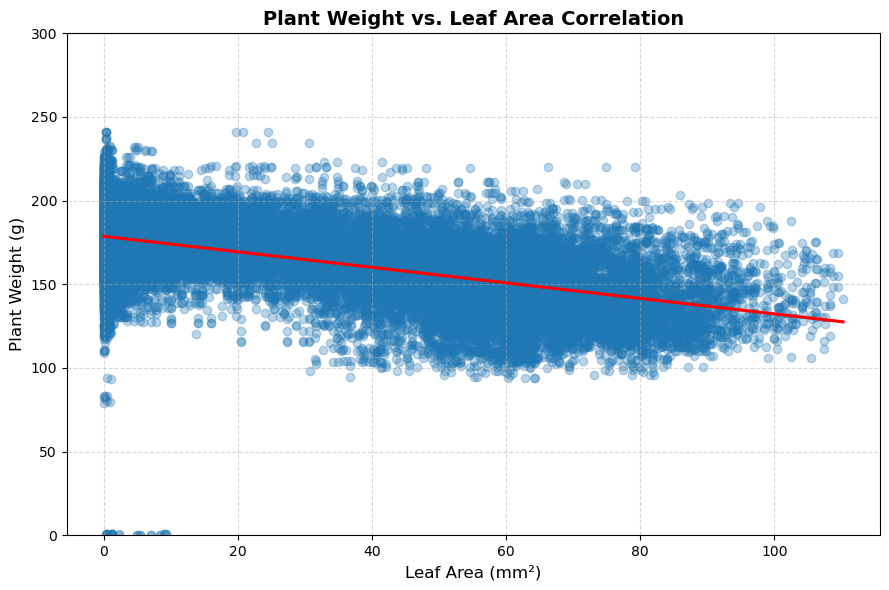

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the CSV datasets
df_weights = pd.read_csv('plant-weights(in).csv')
df_rgb2 = pd.read_csv('rgb2-features(in).csv')

# 2. Normalize and clean date columns for merging
df_weights['date_clean'] = pd.to_datetime(df_weights['date']).dt.normalize()
df_rgb2['date_clean'] = pd.to_datetime(df_rgb2['date']).dt.normalize()

# 3. Merge datasets based on plant_id and date
merged = pd.merge(df_weights, df_rgb2, on=['plant_id', 'date_clean'], suffixes=('_weight', '_rgb'))
valid_data = merged.dropna(subset=['weight_g', 'area_mm2'])

# 4. Generate the scatter plot with a regression trendline
plt.figure(figsize=(9, 6))
sns.regplot(
    data=valid_data, 
    x='area_mm2', 
    y='weight_g', 
    scatter_kws={'alpha': 0.3}, 
    line_kws={'color': 'red'}
)

# Customize plot labels, grid, and y-axis limits
plt.title('Plant Weight vs. Leaf Area Correlation', fontsize=14, fontweight='bold')
plt.xlabel('Leaf Area (mm²)', fontsize=12)
plt.ylabel('Plant Weight (g)', fontsize=12)
plt.ylim(0, 300)  # <-- Sets the y-axis range from 0 to 300
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save and display the plot
plt.savefig('plant_weight_vs_leaf_area_limit300.png', dpi=300)
plt.show()

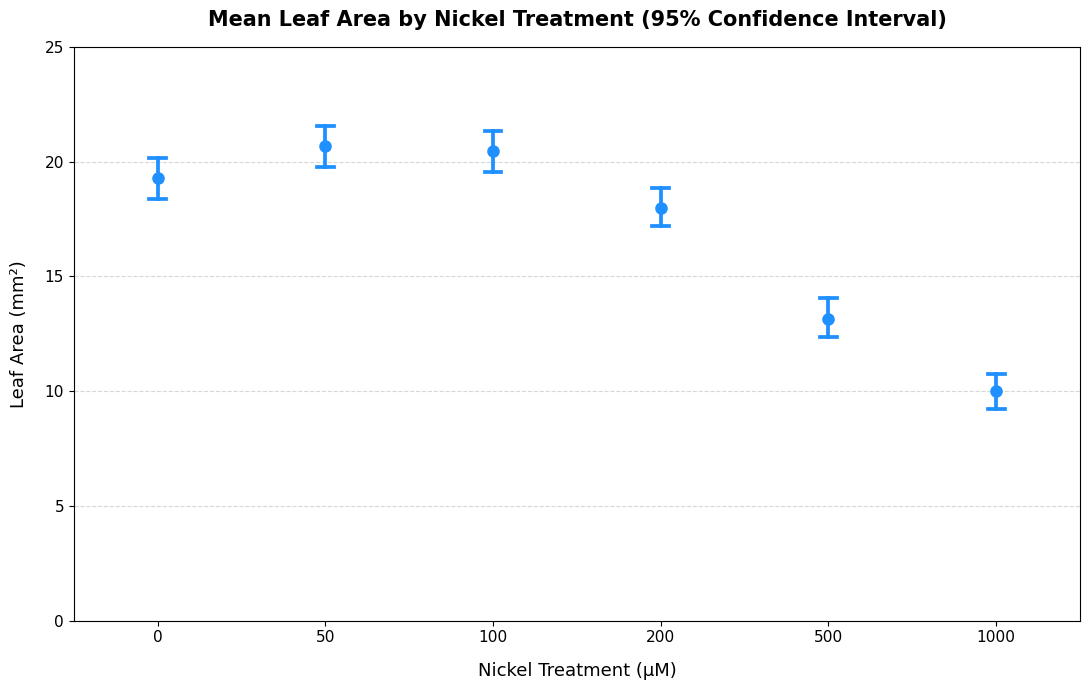

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the design and features datasets
df_design = pd.read_csv('rgb2-design(in).csv')
df_features = pd.read_csv('rgb2-features(in).csv')

# 2. Merge datasets on 'sample_key'
df_merged = pd.merge(df_design, df_features[['sample_key', 'area_mm2']], on='sample_key', how='inner')

# Sort treatments numerically
df_merged['treatment'] = pd.Categorical(df_merged['treatment'], categories=sorted(df_merged['treatment'].unique()), ordered=True)

# 3. Create the point plot with fixed parameters
plt.figure(figsize=(11, 7))
sns.pointplot(
    data=df_merged, 
    x='treatment', 
    y='area_mm2', 
    color='dodgerblue',
    errorbar=('ci', 95),
    linestyle='none',  # <-- Fixed: Replaced join=False with linestyle='none'
    markers='o',
    markersize=7,
    capsize=0.1
)

# Customize plot labels and formatting
plt.title('Mean Leaf Area by Nickel Treatment (95% Confidence Interval)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Nickel Treatment (µM)', fontsize=13, labelpad=12)
plt.ylabel('Leaf Area (mm²)', fontsize=13, labelpad=12)
plt.ylim(0, 25)

# Adjust tick label sizes and add grid
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()

# Save and display the plot
plt.savefig('nickel_treatment_pointplot.png', dpi=300)
plt.show()

       weight_with_pot_before  weight_without_pot_before  \
count            77256.000000               77256.000000   
mean               164.790859                 144.790859   
std                 29.861512                  29.861512   
min                  0.000000                 -20.000000   
25%                157.000000                 137.000000   
50%                170.500000                 150.500000   
75%                182.400000                 162.400000   
max               1004.100000                 984.100000   

       weight_with_pot_after  weight_without_pot_after  
count           62190.000000              62190.000000  
mean              178.839190                158.839190  
std                15.739573                 15.739573  
min                 0.000000                -20.000000  
25%               170.000000                150.000000  
50%               178.600000                158.600000  
75%               188.500000                168.500000  
max

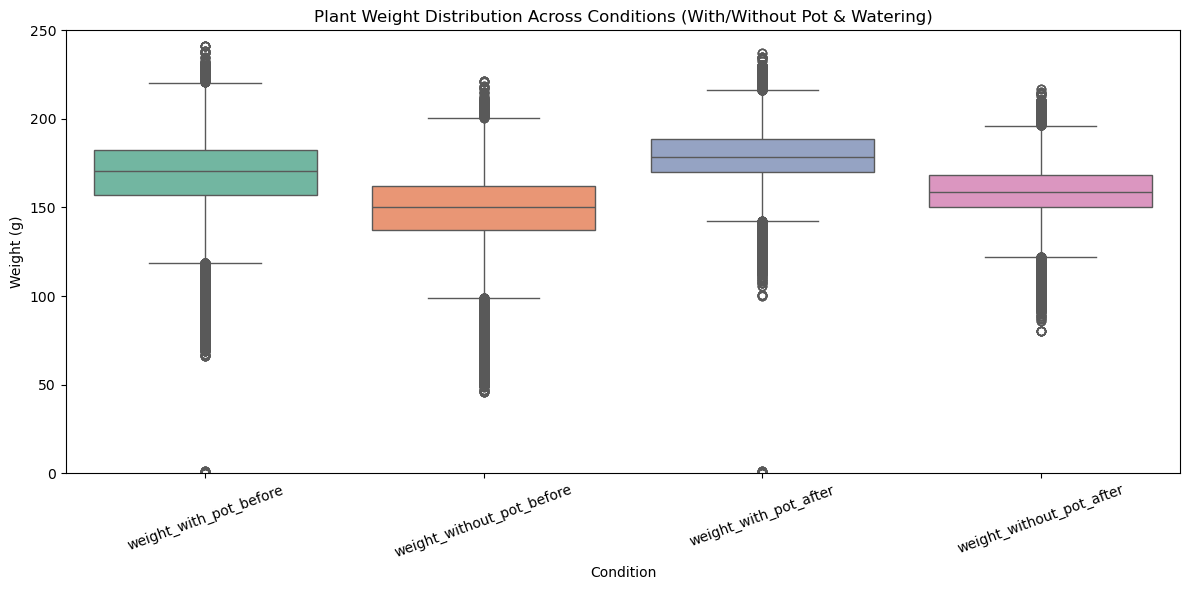

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load and combine all three CSV files
file_names = [
    'plant-weights(in).csv',
    'plant-weights1(in).csv',
    'plant-weights2(in).csv',
]
combined_df = pd.concat([pd.read_csv(f) for f in file_names], ignore_index=True)

# 2. Define your pot weight (in grams)
pot_weight = 20.0

# 3. Calculate weights with and without pot, before and after watering
combined_df['weight_with_pot_before'] = combined_df['weight_g']
combined_df['weight_without_pot_before'] = (
    combined_df['weight_g'] - pot_weight
)

combined_df['weight_with_pot_after'] = combined_df['weight_after_watering_g']
combined_df['weight_without_pot_after'] = (
    combined_df['weight_after_watering_g'] - pot_weight
)

# 4. View summary statistics for all four categories
target_columns = [
    'weight_with_pot_before',
    'weight_without_pot_before',
    'weight_with_pot_after',
    'weight_without_pot_after',
]
print(combined_df[target_columns].describe())

# 5. Reshape data for visualization
melted_df = pd.melt(
    combined_df,
    id_vars=['plant_id'] if 'plant_id' in combined_df.columns else None,
    value_vars=target_columns,
    var_name='Measurement_Condition',
    value_name='Weight_g',
)

# 6. Generate Comparison Graph (Fixed for seaborn palette/hue warning & max y = 250)
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=melted_df,
    x='Measurement_Condition',
    y='Weight_g',
    hue='Measurement_Condition',
    palette='Set2',
)

# Hide duplicate legend if generated
plt.legend([], [], frameon=False)

plt.title('Plant Weight Distribution Across Conditions (With/Without Pot & Watering)')
plt.xlabel('Condition')
plt.ylabel('Weight (g)')
plt.ylim(0, 250)  # Caps the max y-axis at 250
plt.xticks(rotation=20)
plt.tight_layout()

# Save and show the plot
plt.savefig('plant_weights_comparison.png')
plt.show()